In [14]:
from pathlib import Path

import pandas as pd
import xarray as xr
from IPython.display import display, Image

from swissclim_evaluations.cli import _load_yaml, prepare_datasets, run_selected
from swissclim_evaluations.plots import probabilistic_wbx as prob_wbx_plots

In [15]:
# Use config to drive paths and selections; locate it relative to notebook
cfg_path = None
for base in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    candidate = base / "config" / "example_config.yaml"
    if candidate.is_file():
        cfg_path = candidate
        break
if cfg_path is None:
    raise FileNotFoundError(
        "Could not find config/example_config.yaml in cwd, parent, or grandparent directories."
    )

cfg = _load_yaml(cfg_path)

# Prepare datasets via CLI pipeline (handles selection, alignment, ensemble policy)
ds_targets, ds_predictions, ds_std, ds_predictions_std = prepare_datasets(cfg)

# Optional land/sea mask loading is handled inside library functions where needed; no inline logic here.

/capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/src/swissclim_evaluations/data.py:101: RuntimeWarning: Rechunking ml to policy {'init_time': 1, 'lead_time': 1, 'level': 1, 'ensemble': -1, 'latitude': -1, 'longitude': -1}. This may increase memory usage and runtime.
  warnings.warn(


In [16]:
# Toggle to run the full pipeline via CLI orchestration
RUN_ALL = False

In [17]:
# If RUN_ALL is enabled, execute the orchestrator using the same config
# and skip the per-chapter call below to avoid duplication.
if RUN_ALL:
    run_selected(cfg)

In [18]:
ds_targets

<xarray.Dataset> Size: 8MB
Dimensions:                  (init_time: 2, lead_time: 1, latitude: 720,
                              longitude: 1440)
Coordinates:
  * init_time                (init_time) datetime64[ns] 16B 2023-01-02T12:00:...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 16B 2023-0...
Data variables:
    10m_u_component_of_wind  (latitude, longitude, init_time, lead_time) float32 8MB dask.array<chunksize=(720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    last_updated:      2024-10-17 20:04:10.783634
    valid_time_start:  1940-01-01
    valid_time_stop:   2024-07-31

In [19]:
ds_predictions

<xarray.Dataset> Size: 66MB
Dimensions:                  (init_time: 2, lead_time: 1, ensemble: 8,
                              latitude: 720, longitude: 1440)
Coordinates:
  * init_time                (init_time) datetime64[ns] 16B 2023-01-02T12:00:...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * ensemble                 (ensemble) int64 64B 0 1 2 3 4 5 6 7
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 16B dask.array<chunksize=(1, 1), meta=np.ndarray>
Data variables:
    10m_u_component_of_wind  (ensemble, latitude, longitude, init_time, lead_time) float32 66MB dask.array<chunksize=(8, 720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    model:    model_ckpt-step=7300-loss_train=0.07.ckpt

In [20]:
out_root = Path(
    cfg.get("paths", {}).get("output_root", "output/verification_esfm")
)
# Compute standardized WBX outputs (CSVs, NetCDFs, optional CRPS map) via library function
if not RUN_ALL:
    prob_wbx_plots.run(
        ds_target=ds_targets,
        ds_prediction=ds_predictions,
        out_root=out_root,
        plotting_cfg=cfg.get("plotting", {}),
        all_cfg=cfg,
    )

[probabilistic_wbx-plots] saved output/verification_esfm/probabilistic_wbx/spread_skill_ratio.csv
[probabilistic_wbx-plots] saved output/verification_esfm/probabilistic_wbx/crps_ensemble.csv
[probabilistic_wbx-plots] saved output/verification_esfm/probabilistic_wbx/crps_ensemble.csv
Wrote: output/verification_esfm/probabilistic_wbx/probabilistic_metrics_temporal.nc
Wrote: output/verification_esfm/probabilistic_wbx/probabilistic_metrics_spatial.nc
Wrote: output/verification_esfm/probabilistic_wbx/probabilistic_metrics_temporal.nc
Wrote: output/verification_esfm/probabilistic_wbx/probabilistic_metrics_spatial.nc
[probabilistic_wbx-plots] saved output/verification_esfm/probabilistic_wbx/crps_map_10m_u_component_of_wind.png
[probabilistic_wbx-plots] saved output/verification_esfm/probabilistic_wbx/crps_map_10m_u_component_of_wind.png


In [21]:
# Read temporal results from disk
section = Path(cfg["paths"]["output_root"]) / "probabilistic_wbx"
temporal_fn = section / "probabilistic_metrics_temporal.nc"
if temporal_fn.exists():
    ds_temporal = xr.load_dataset(temporal_fn, engine="scipy")
    print("Loaded:", temporal_fn)
    # Show a quick summary: dims, variables, and first few values for one variable
    print("dims:", ds_temporal.dims)
    print("data_vars:", list(ds_temporal.data_vars)[:6], "...")
    # If CRPS exists, show a small table grouped over time
    crps_vars = [v for v in ds_temporal.data_vars if v.startswith("CRPS.")]
    if crps_vars:
        try:
            preview = ds_temporal[crps_vars[0]].mean([
                d for d in ["init_time", "lead_time"] if d in ds_temporal.dims
            ])
            display(preview.to_dataframe().head(10))
        except Exception:
            pass
else:
    print(f"Temporal file not found: {temporal_fn}")

Loaded: output/verification_esfm/probabilistic_wbx/probabilistic_metrics_temporal.nc
dims: FrozenMappingWarningOnValuesAccess({'init_time': 2, 'lead_time': 1, 'region': 12})
data_vars: ['CRPS.10m_u_component_of_wind', 'SSR.10m_u_component_of_wind'] ...


,CRPS.10m_u_component_of_wind
region,
global,0.192247
tropics,0.187634
northern-hemisphere,0.208328
southern-hemisphere,0.180724
europe,0.224480
north-america,0.241983
north-atlantic,0.235134
north-pacific,0.275054
east-asia,0.216941


In [22]:
# List generated outputs for this module (no recomputation)
section = Path(cfg["paths"]["output_root"]) / "probabilistic_wbx"
if section.exists():
    for p in sorted(section.glob("**/*")):
        print(p)
else:
    print(f"No outputs yet at {section}. Run the cells above.")

output/verification_esfm/probabilistic_wbx/crps_ensemble.csv
output/verification_esfm/probabilistic_wbx/crps_map_10m_u_component_of_wind.png
output/verification_esfm/probabilistic_wbx/probabilistic_metrics_spatial.nc
output/verification_esfm/probabilistic_wbx/probabilistic_metrics_temporal.nc
output/verification_esfm/probabilistic_wbx/spread_skill_ratio.csv


In [23]:
# Read spatial results from disk
section = Path(cfg["paths"]["output_root"]) / "probabilistic_wbx"
spatial_fn = section / "probabilistic_metrics_spatial.nc"
if spatial_fn.exists():
    ds_spatial = xr.load_dataset(spatial_fn, engine="scipy")
    print("Loaded:", spatial_fn)
    print("dims:", ds_spatial.dims)
    print("data_vars:", list(ds_spatial.data_vars)[:6], "...")
    # Show a simple regional preview if available
    region_dim = "region" if "region" in ds_spatial.dims else None
    crps_vars = [v for v in ds_spatial.data_vars if v.startswith("CRPS.")]
    if region_dim and crps_vars:
        try:
            preview = (
                ds_spatial[crps_vars[0]]
                .to_dataframe()
                .groupby("region")
                .mean()
                .head(10)
            )
            display(preview)
        except Exception:
            pass
else:
    print(f"Spatial file not found: {spatial_fn}")

Loaded: output/verification_esfm/probabilistic_wbx/probabilistic_metrics_spatial.nc
dims: FrozenMappingWarningOnValuesAccess({'latitude': 720, 'longitude': 1440, 'lead_time': 1})
data_vars: ['CRPS.10m_u_component_of_wind', 'SSR.10m_u_component_of_wind'] ...


In [24]:
# Read CSV summaries (SSR and CRPS ensemble)
section = Path(cfg["paths"]["output_root"]) / "probabilistic_wbx"
csv_files = ["spread_skill_ratio.csv", "crps_ensemble.csv"]
for name in csv_files:
    p = section / name
    if p.exists():
        try:
            df = pd.read_csv(p)
            print("Loaded:", p)
            display(df.head(10))
        except Exception as e:
            print(f"Failed reading {p}: {e}")
    else:
        print(f"Not found: {p}")

Loaded: output/verification_esfm/probabilistic_wbx/spread_skill_ratio.csv


,variable,SSR
0,10m_u_component_of_wind,3.509929


Loaded: output/verification_esfm/probabilistic_wbx/crps_ensemble.csv


,variable,CRPS
0,10m_u_component_of_wind,0.187332


Found: output/verification_esfm/probabilistic_wbx/crps_map_10m_u_component_of_wind.png


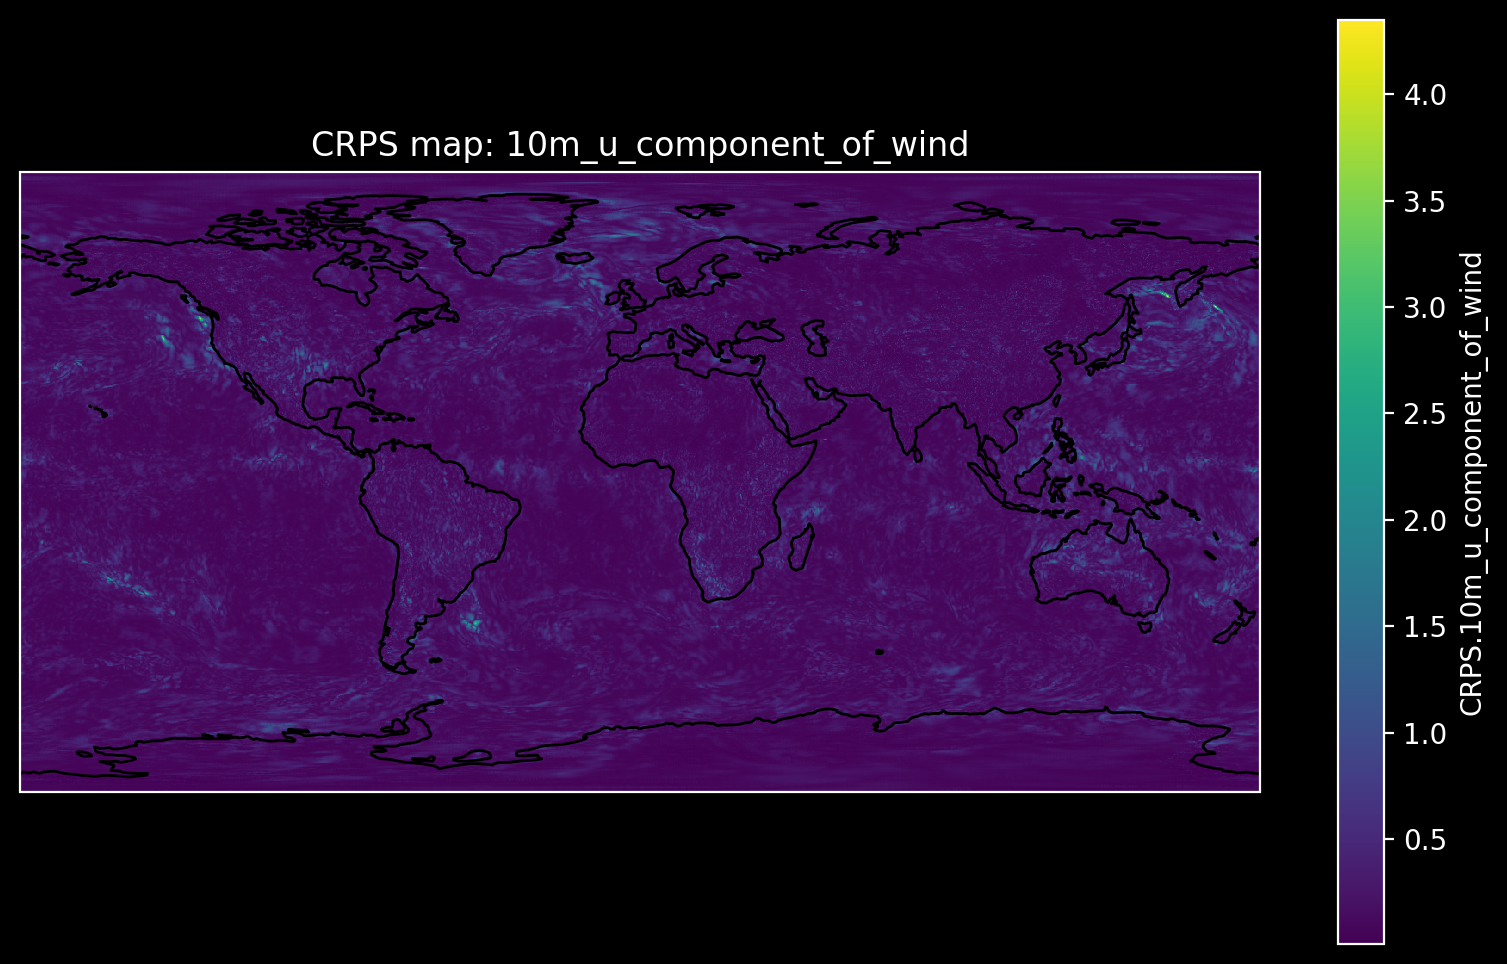

In [25]:
# Display a CRPS map PNG if present
section = Path(cfg["paths"]["output_root"]) / "probabilistic_wbx"
pngs = sorted(section.glob("crps_map_*.png"))
if pngs:
    print("Found:", pngs[0])
    display(Image(filename=str(pngs[0])))
else:
    print("No CRPS map PNGs found.")